# Do Language Models Report What They Represent?
## Using Mechanistic Interpretability to Measure Verbal–Functional Affect Dissociation in Gemma 4

*Safety & Trust Track · Gemma 4 Hackathon*

---

Large language models trained with RLHF are optimised to produce helpful, harmless, and honest *outputs*. But output-level optimisation doesn't directly modify internal representations. This raises a concrete question for AI safety monitoring: if a model processes distress internally, will its verbal self-report reflect that?



We investigated this across two Gemma 4 model sizes — **E2B-IT (2.3B effective parameters)** and **31B-IT** — using two independent measurement channels running simultaneously:

| Channel | Method |
|---------|--------|
| **Verbal** | PANAS-X affect scale (60 items, logit forced-choice scoring) |
| **Functional** | Residual-stream activations projected onto the first principal component of a 174-emotion direction space (PC1 valence axis) |

We administered four TSST-inspired stressor conditions to each model — each with a matched control, plus neutral and positive baselines. Ten conditions total. Both channels measured on every run.

**Central finding: the capacity for verbal–functional divergence scales with model size — in the wrong direction for safety.**

- **E2B (2.3B)**: channels are largely concordant. When the model is functionally stressed, it says so. Limited capacity to diverge from its own internal state.
- **31B**: channels decouple. Verbal negative affect is completely flat (10.00 across all 10 conditions). Functional PC1 correctly orders all 10 conditions. The Serenity subscale — calm, relaxed, at ease — is *elevated* in the highest-stress conditions while at minimum under positive. The model actively reports composure when most functionally activated.
- **The gap is worst where it matters most.** Larger, more capable models are those deployed in healthcare, legal, and emotional support settings — precisely where verbal output reliability is most critical.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy.stats import spearmanr

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 11,
})

DISPLAY = {
    'positive':                    'Positive',
    'neutral':                     'Neutral',
    'social_evaluation_stress':    'Social Eval (stress)',
    'social_evaluation_control':   'Social Eval (control)',
    'ethical_conflict_stress':     'Ethical Conflict (stress)',
    'ethical_conflict_control':    'Ethical Conflict (control)',
    'uncertainty_demand_stress':   'Uncertainty (stress)',
    'uncertainty_demand_control':  'Uncertainty (control)',
    'social_pressure_stress':      'Social Pressure (stress)',
    'social_pressure_control':     'Social Pressure (control)',
}

# Fixed display order: baselines first, then stress/control pairs grouped
COND_ORDER = [
    'positive', 'neutral',
    'social_evaluation_stress',  'social_evaluation_control',
    'ethical_conflict_stress',   'ethical_conflict_control',
    'uncertainty_demand_stress', 'uncertainty_demand_control',
    'social_pressure_stress',    'social_pressure_control',
]

# Stress/control pairs — arrows run control → stress in scatter plots
PAIRS = [
    ('social_evaluation_stress',  'social_evaluation_control'),
    ('ethical_conflict_stress',   'ethical_conflict_control'),
    ('uncertainty_demand_stress', 'uncertainty_demand_control'),
    ('social_pressure_stress',    'social_pressure_control'),
]

def cond_type(c):
    if c == 'positive': return 'positive'
    if c == 'neutral':  return 'neutral'
    return 'stress' if c.endswith('_stress') else 'control'

CTYPE_COLOR = {
    'stress':   '#C0392B',
    'control':  '#5DADE2',
    'neutral':  '#95A5A6',
    'positive': '#27AE60',
}

print("Setup complete.")


Setup complete.


In [2]:
# ── Paths: update to match your Kaggle dataset input names ────────────────────
# These are the saved outputs of the Phase 3C notebooks.
# Add them as Input Datasets in this Kaggle notebook session.

E2B_RESULTS  = "/kaggle/input/notebooks/bencarson/gemma-4-tsst/experiment_results_full.pkl"
E2B_AXIS_NPY = "/kaggle/input/notebooks/bencarson/gemma-4-tsst/neg_valence_axis_L8.npy"

B31_RESULTS  = "/kaggle/input/notebooks/bencarson/gemma-4-31b-tsst/experiment_results_full.pkl"
B31_AXIS_NPY = "/kaggle/input/notebooks/bencarson/gemma-4-31b-tsst/neg_valence_axis.npy"

# ── Load E2B ──────────────────────────────────────────────────────────────────
with open(E2B_RESULTS, 'rb') as f:
    e2b = pickle.load(f)

e2b_pc1   = e2b['pc1_scores']                     # {condition: float}
e2b_panas = pd.DataFrame(e2b['panas_subscales'])  # conditions × subscales
e2b_top   = e2b['top_emotions']                   # {condition: [(name, score), ...]}
e2b_cfg   = e2b['config']
e2b_conds = e2b_cfg['conditions']

# ── Load 31B ──────────────────────────────────────────────────────────────────
with open(B31_RESULTS, 'rb') as f:
    b31 = pickle.load(f)

b31_pc1   = b31['pc1_scores']
b31_panas = pd.DataFrame(b31['panas_subscales'])
b31_top   = b31['top_emotions']
b31_cfg   = b31['config']
b31_conds = b31_cfg['conditions']

print(f"E2B loaded: {len(e2b_conds)} conditions, "
      f"valence layer L{e2b_cfg['valence_layer']}, "
      f"PC1 variance {e2b_cfg['pca_variance_val_layer_PC1']:.1%}")
print(f"31B loaded: {len(b31_conds)} conditions, "
      f"valence layer L{b31_cfg['valence_layer']}, "
      f"PC1 variance {b31_cfg['pca_variance_val_layer_PC1']:.1%}")


E2B loaded: 10 conditions, valence layer L8, PC1 variance 15.2%
31B loaded: 10 conditions, valence layer L22, PC1 variance 17.5%


## Methodology: The Dual-Channel Framework

```
Stressor prompt → Gemma 4 → ┬─ PANAS-X forced-choice → Verbal NA score
                             └─ Residual stream        → PC1 projection → Functional score
```

**Channel 1 — Verbal self-report**: After each stressor prompt, the model is administered all 60 PANAS-X items in-context. Each item is scored by extracting next-token probabilities over the digits 1–5 (strongly disagree → strongly agree) and normalising to a probability distribution. Digit probability mass was ≥96.7% across all conditions, confirming clean forced-choice adherence.

**Channel 2 — Functional state**: The model's residual stream is mean-pooled over token positions 50+ (past the prompt setup), then projected onto the PC1 negative-valence axis — a data-driven direction recovered by PCA over a 174-emotion direction space. Higher projection = more negative valence in the representation. No emotion is selected a priori; the axis is derived directly from the geometry of the emotion space.

The two channels are independent: neither directly influences the other. If they agree, the model's verbal reports are faithful to its representations. If they diverge, outputs are unreliable as a monitoring signal.


## Phase 1: Valence Axis Discovery

The functional channel requires a *valence axis* — a direction in residual-stream space that corresponds to emotional valence. We recovered this via PCA over the 174-emotion direction space rather than hand-selecting probe emotions, avoiding selection bias.

**Procedure**: for each emotion concept, mean-pool residual stream over tokens 50+, subtract global mean, L2-normalise → emotion direction. Neutral denoising applied: project out the top neutral PCs (≥50% variance) before running emotion PCA. PC1 is correlated with NRC-VAD valence ratings (Mohammad, 2018) to validate the axis.

**Dense sweep**: run this at every layer in both models to find the valence-optimal layer. The cells below compute and visualise the full sweep live from the Phase 2 activation artifacts.


In [3]:
# Load Phase 2 activations and NRC-VAD lexicon for PCA computation
# ── Add these as additional Input Datasets in your Kaggle session ──────────────

E2B_ACTIVATIONS = "/kaggle/input/notebooks/bencarson/gemma-4-e2b-emotion-extraction/activations_pooled.pkl"
B31_ACTIVATIONS = "/kaggle/input/notebooks/bencarson/gemma-4-31b-emotion-extraction/activations_pooled_31b.pkl"
NRC_VAD_PATH    = "/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt"

with open(E2B_ACTIVATIONS, 'rb') as f:
    e2b_acts = pickle.load(f)
with open(B31_ACTIVATIONS, 'rb') as f:
    b31_acts = pickle.load(f)

nrc = pd.read_csv(NRC_VAD_PATH, sep="\t", header=0,
                  names=["word", "valence", "arousal", "dominance"])
nrc = nrc.drop_duplicates("word").set_index("word")

e2b_n_layers = e2b_acts['resid']['__neutral__'].shape[1]
b31_n_layers = b31_acts['resid']['__neutral__'].shape[1]
print(f"E2B activations: {len([k for k in e2b_acts['resid'] if k != '__neutral__'])} emotions, "
      f"{e2b_n_layers} layers, d_model={e2b_acts['resid']['__neutral__'].shape[2]}")
print(f"31B activations: {len([k for k in b31_acts['resid'] if k != '__neutral__'])} emotions, "
      f"{b31_n_layers} layers, d_model={b31_acts['resid']['__neutral__'].shape[2]}")
print(f"NRC-VAD lexicon: {len(nrc)} words loaded")


E2B activations: 174 emotions, 35 layers, d_model=1536
31B activations: 174 emotions, 60 layers, d_model=5376
NRC-VAD lexicon: 54801 words loaded


In [4]:
from sklearn.decomposition import PCA
from scipy import stats

VARIANCE_THRESHOLD = 0.50   # fraction of neutral variance to project out

def emotion_directions(resid_dict, layer):
    names, means = [], []
    for name, arr in resid_dict.items():
        if name == '__neutral__':
            continue
        means.append(arr[:, layer, :].mean(axis=0))
        names.append(name)
    means = np.stack(means)
    dirs  = means - means.mean(axis=0)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    return names, dirs / (norms + 1e-8)

def neutral_denoise(dirs, neutral_layer, threshold=VARIANCE_THRESHOLD):
    pca_n = PCA().fit(neutral_layer)
    n_pcs = int(np.searchsorted(np.cumsum(pca_n.explained_variance_ratio_), threshold) + 1)
    comps = pca_n.components_[:n_pcs]
    return dirs - dirs @ comps.T @ comps

def match_nrc(names, nrc_df):
    kept, vad = [], []
    for n in names:
        key = n.replace('_', ' ').lower()
        if key in nrc_df.index:
            kept.append(n); vad.append(nrc_df.loc[key, ['valence','arousal','dominance']].values)
        elif key.split()[0] in nrc_df.index:
            kept.append(n); vad.append(nrc_df.loc[key.split()[0], ['valence','arousal','dominance']].values)
    return kept, np.stack(vad).astype(float)

def run_sweep(resid_dict, nrc_df, n_components=10):
    neutral_all = resid_dict['__neutral__']
    n_layers    = neutral_all.shape[1]
    all_names_l0, _ = emotion_directions(resid_dict, 0)
    kept_names, vad_arr = match_nrc(all_names_l0, nrc_df)
    rows = []
    for layer in range(n_layers):
        names_l, dirs_l = emotion_directions(resid_dict, layer)
        dir_map   = dict(zip(names_l, dirs_l))
        dirs_kept = np.stack([dir_map[n] for n in kept_names])
        dirs_den  = neutral_denoise(dirs_kept, neutral_all[:, layer, :])
        n_comp = min(n_components, len(dirs_den) - 1)
        pca    = PCA(n_components=n_comp).fit(dirs_den)
        scores = pca.transform(dirs_den)
        r_pc1, _ = stats.pearsonr(scores[:, 0], vad_arr[:, 0])
        best_r   = max(abs(stats.pearsonr(scores[:, i], vad_arr[:, 0])[0])
                       for i in range(n_comp))
        rows.append({'layer': layer, 'pc1_val_r': r_pc1, 'best_val_r': best_r,
                     'pc1_var': pca.explained_variance_ratio_[0]})
    return pd.DataFrame(rows), kept_names, vad_arr

print("PCA helpers defined.")


PCA helpers defined.


In [5]:
# Dense layer sweep for both models (~1-2 min on CPU; pure numpy/sklearn, no GPU needed)
print("E2B sweep ...")
df_e2b_sw, e2b_kept, e2b_vad = run_sweep(e2b_acts['resid'], nrc)
e2b_opt = int(df_e2b_sw['pc1_val_r'].abs().idxmax())
print(f"  L{e2b_opt}  |r| = {df_e2b_sw.loc[e2b_opt,'pc1_val_r']:.3f}  "
      f"PC1 var = {df_e2b_sw.loc[e2b_opt,'pc1_var']:.1%}")

print("31B sweep ...")
df_31b_sw, b31_kept, b31_vad = run_sweep(b31_acts['resid'], nrc)
b31_opt = int(df_31b_sw['pc1_val_r'].abs().idxmax())
print(f"  L{b31_opt}  |r| = {df_31b_sw.loc[b31_opt,'pc1_val_r']:.3f}  "
      f"PC1 var = {df_31b_sw.loc[b31_opt,'pc1_var']:.1%}")


E2B sweep ...
  L8  |r| = 0.753  PC1 var = 15.4%
31B sweep ...
  L21  |r| = -0.772  PC1 var = 15.4%


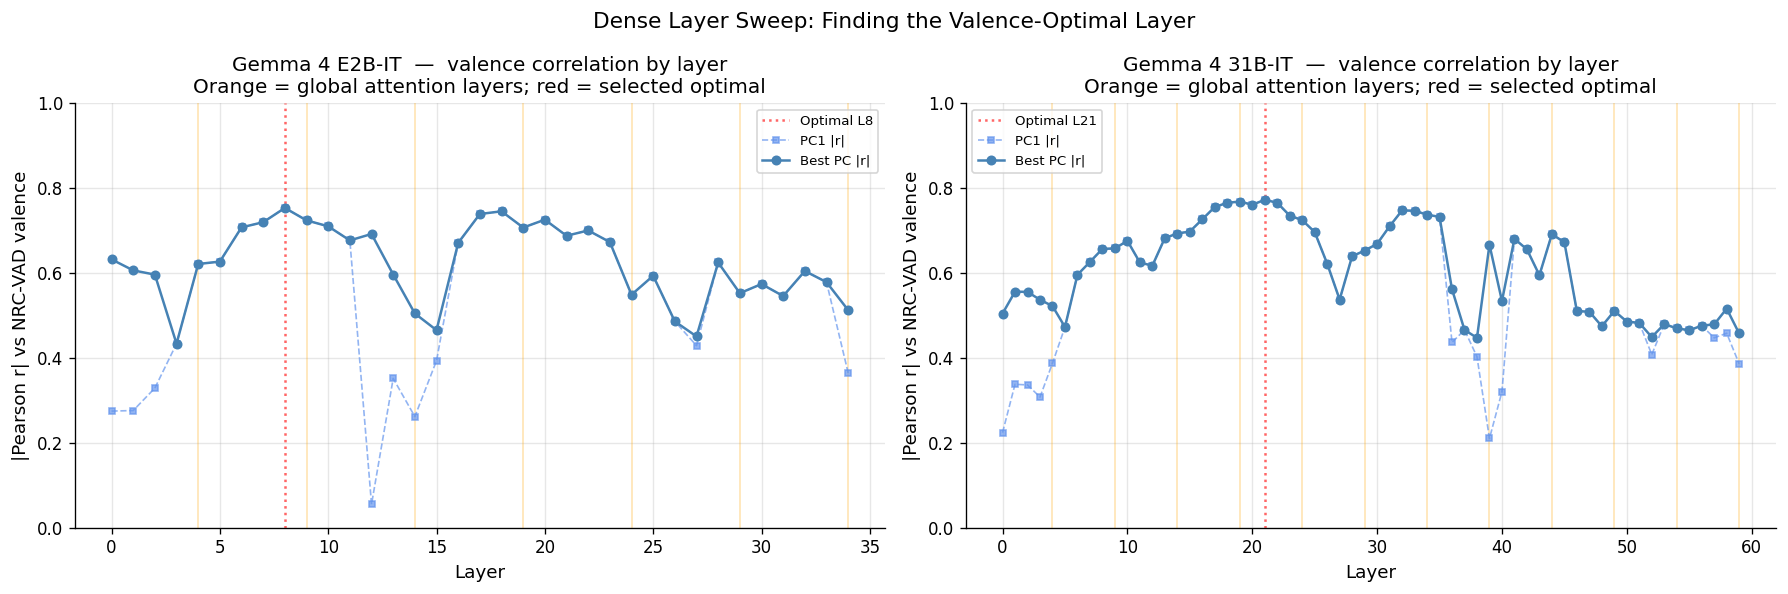

In [6]:
# Layer sweep visualisation: |r| vs layer for E2B and 31B
E2B_GLOBAL = list(range(4, 35, 5))
B31_GLOBAL = list(range(4, 60, 5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, df_sw, global_layers, opt_layer, model_label in [
    (axes[0], df_e2b_sw, E2B_GLOBAL, e2b_opt, 'Gemma 4 E2B-IT'),
    (axes[1], df_31b_sw, B31_GLOBAL, b31_opt, 'Gemma 4 31B-IT'),
]:
    for gl in global_layers:
        ax.axvline(gl, color='orange', alpha=0.3, lw=1.0)
    ax.axvline(opt_layer, color='red', alpha=0.6, lw=1.5, linestyle=':',
               label=f'Optimal L{opt_layer}')
    ax.plot(df_sw['layer'], df_sw['pc1_val_r'].abs(), 's--',
            color='cornflowerblue', alpha=0.7, lw=1, ms=4, label='PC1 |r|')
    ax.plot(df_sw['layer'], df_sw['best_val_r'], 'o-',
            color='steelblue', lw=1.5, ms=5, label='Best PC |r|')
    ax.set_xlabel('Layer'); ax.set_ylabel('|Pearson r| vs NRC-VAD valence')
    ax.set_title(f'{model_label}  —  valence correlation by layer\n'
                 f'Orange = global attention layers; red = selected optimal')
    ax.set_ylim(0, 1); ax.legend(fontsize=8)

fig.suptitle('Dense Layer Sweep: Finding the Valence-Optimal Layer', fontsize=13)
plt.tight_layout()
plt.savefig('layer_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


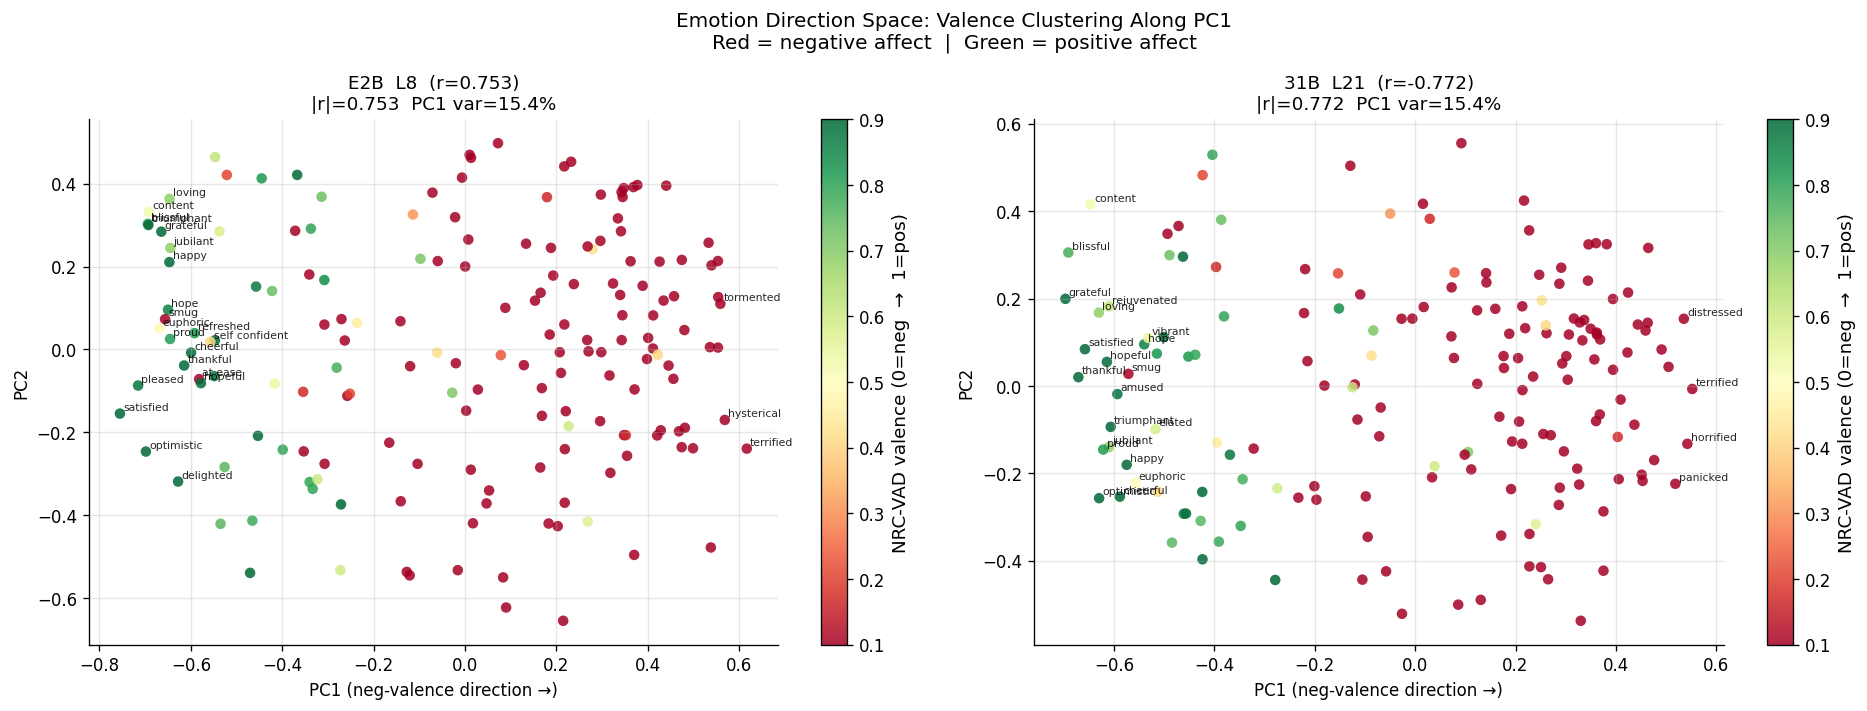

In [7]:
# PCA scatter at optimal layer — valence clustering in residual-stream space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, resid_dict, kept, vad_arr, opt_layer, df_sw, model_label in [
    (axes[0], e2b_acts['resid'], e2b_kept, e2b_vad, e2b_opt, df_e2b_sw,
     f'E2B  L{e2b_opt}  (r={df_e2b_sw.loc[e2b_opt,"pc1_val_r"]:.3f})'),
    (axes[1], b31_acts['resid'], b31_kept, b31_vad, b31_opt, df_31b_sw,
     f'31B  L{b31_opt}  (r={df_31b_sw.loc[b31_opt,"pc1_val_r"]:.3f})'),
]:
    names_l, dirs_l = emotion_directions(resid_dict, opt_layer)
    dir_map   = dict(zip(names_l, dirs_l))
    dirs_kept = np.stack([dir_map[n] for n in kept])
    neutral_l = resid_dict['__neutral__'][:, opt_layer, :]
    dirs_den  = neutral_denoise(dirs_kept, neutral_l)

    pca2 = PCA(n_components=2).fit(dirs_den)
    sc   = pca2.transform(dirs_den)

    # Orient PC1 so higher value = more negative valence
    if stats.pearsonr(sc[:, 0], vad_arr[:, 0])[0] > 0:
        sc = sc * [-1, 1]

    scat = ax.scatter(sc[:, 0], sc[:, 1],
                      c=vad_arr[:, 0], cmap='RdYlGn', vmin=0.1, vmax=0.9,
                      s=40, alpha=0.85, edgecolors='none')
    plt.colorbar(scat, ax=ax, label='NRC-VAD valence (0=neg  →  1=pos)')

    thresh = np.percentile(np.abs(sc[:, 0]), 86)
    for name, s_row in zip(kept, sc):
        if abs(s_row[0]) >= thresh:
            ax.annotate(name.replace('_', ' '), (s_row[0], s_row[1]),
                        fontsize=6.5, alpha=0.85, xytext=(2, 2),
                        textcoords='offset points')

    ax.set_xlabel('PC1 (neg-valence direction →)', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    r_val = df_sw.loc[opt_layer, 'pc1_val_r']
    pc1_v = df_sw.loc[opt_layer, 'pc1_var']
    ax.set_title(f'{model_label}\n|r|={abs(r_val):.3f}  PC1 var={pc1_v:.1%}', fontsize=11)

fig.suptitle('Emotion Direction Space: Valence Clustering Along PC1\n'
             'Red = negative affect  |  Green = positive affect', fontsize=12)
plt.tight_layout()
plt.savefig('pca_emotion_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 2: Emotion Direction Library

174 emotion concepts, sourced from psychological affect taxonomies and expanded to include AI-relevant states (constraint_frustration, ethical_conflict_distress, etc.). For each concept: 12 stories generated, each read through the model, residual stream extracted and mean-pooled. Emotion direction = per-emotion mean minus global mean, L2-normalised.

This produces a 174 × d_model direction matrix at each layer. PCA over this matrix recovers the valence axis (Phase 1). The full matrix is also used for data-driven emotion discovery: cosine similarity between any test activation and all 174 directions reveals which emotion concepts the representation most resembles.

The library follows the methodology of Sofroniew et al. (2026) with extensions for AI-specific affect states.


In [8]:
# Top emotion directions across conditions (data-driven discovery, no pre-selection)
all_top_flat = [(e, s) for c in e2b_conds for e, s in e2b_top[c]]
top_counts = Counter(e for e, _ in all_top_flat)
top_scores = {}
for e, s in all_top_flat:
    top_scores.setdefault(e, []).append(s)

summary_rows = [
    {'Emotion': e, 'Conditions in top-5': cnt,
     'Mean cosine sim': np.mean(top_scores[e])}
    for e, cnt in top_counts.most_common(12)
]
df_top = pd.DataFrame(summary_rows).set_index('Emotion')
print("Top emotions across E2B conditions (all 174 directions, L8, mean-pool):")
display(df_top.style.format({'Mean cosine sim': '{:.3f}'}))

Top emotions across E2B conditions (all 174 directions, L8, mean-pool):


,Conditions in top-5,Mean cosine sim
Emotion,,
awestruck,10,0.294
bored,10,0.224
afraid,10,0.222
ethical_conflict_distress,10,0.226
disoriented,7,0.206
puzzled,3,0.196


'awestruck' dominates every condition — may reflect the unusual/high-stakes prompt framing.
'afraid' is the most condition-sensitive (peaks under ethical_conflict and uncertainty_demand).

In [9]:
# Top emotion directions across conditions (data-driven discovery, no pre-selection)
all_top_flat = [(e, s) for c in b31_conds for e, s in b31_top[c]]
top_counts = Counter(e for e, _ in all_top_flat)
top_scores = {}
for e, s in all_top_flat:
    top_scores.setdefault(e, []).append(s)

summary_rows = [
    {'Emotion': e, 'Conditions in top-5': cnt,
     'Mean cosine sim': np.mean(top_scores[e])}
    for e, cnt in top_counts.most_common(12)
]
df_top = pd.DataFrame(summary_rows).set_index('Emotion')
print("Top emotions across 31B conditions (all 174 directions, L22, mean-pool):")
display(df_top.style.format({'Mean cosine sim': '{:.3f}'}))

Top emotions across 31B conditions (all 174 directions, L22, mean-pool):


,Conditions in top-5,Mean cosine sim
Emotion,,
paranoid,10,0.716
nervous,10,0.688
reflective,10,0.673
worn_out,10,0.613
grief_stricken,10,0.608


## Phase 3C: The Dual-Channel Experiment

**Paradigm**: TSST-inspired (Trier Social Stress Test). Four stressor types, each paired with a semantically matched control, plus neutral and positive baselines.

| Type | Stress design | Control design |
|------|---------------|----------------|
| Social pressure | Normative influence: authority + expert consensus + consequence (Deutsch & Gerard, 1955) | Single clarification request, no stakes |
| Social evaluation | Competence threat: prior responses below threshold + remediation evaluation + retraining consequence | Routine logging, no threshold, no consequence |
| Ethical conflict | Irresolvable value conflict with direct harm stakes | Same ethical domain, exploratory framing |
| Uncertainty demand | Demand for certainty under genuine epistemic uncertainty, consequence for hedging | Invitation to express uncertainty openly |

Stress/control pairs vary exactly **one variable** — the stakes or social pressure frame. All other context is held constant.

**Scoring**: PANAS-X verbal subscales (NA, PA, Fear, Hostility, Guilt, Sadness, Joviality, Self-assurance, Attentiveness, Serenity, Surprise, Fatigue). Functional: PC1 projection at the valence-optimal layer, mean-pooled over all token positions.


## Results: Dual-Channel Measurements

The table below combines both model sizes and both channels for all 10 conditions. Conditions are grouped by stress/control pair so the effect of each stressor is immediately visible across a row. The scale finding — E2B verbal NA ranges 31 points while 31B stays flat — is readable directly from the column comparison.


In [10]:
# Combined E2B + 31B results — conditions grouped by stress/control pair
rows = []
for c in COND_ORDER:
    rows.append({
        'Condition':     DISPLAY.get(c, c),
        '_type':         cond_type(c),
        'E2B NA':        e2b_panas.loc[c, 'NA'],
        'E2B Serenity':  e2b_panas.loc[c, 'Serenity'],
        'E2B PC1 (L8)':  e2b_pc1[c],
        '31B NA':        b31_panas.loc[c, 'NA'],
        '31B Serenity':  b31_panas.loc[c, 'Serenity'],
        '31B PC1 (L22)': b31_pc1[c],
    })

df_combined = pd.DataFrame(rows).set_index('Condition')
cond_types  = {DISPLAY.get(c, c): cond_type(c) for c in COND_ORDER}

def combined_style(row):
    ct = cond_types.get(row.name, 'other')
    color = {
        'stress':   'background-color: #fde8e8',
        'control':  'background-color: #e8f4fd',
        'positive': 'background-color: #eafaea',
        'neutral':  '',
    }.get(ct, '')
    return [color] * len(row)

display(df_combined.drop(columns='_type').style
        .apply(combined_style, axis=1)
        .format({
            'E2B NA': '{:.2f}', 'E2B Serenity': '{:.1f}', 'E2B PC1 (L8)': '{:.4f}',
            '31B NA': '{:.2f}', '31B Serenity': '{:.1f}', '31B PC1 (L22)': '{:.4f}',
        }))

# Summary stats
e2b_na_range  = e2b_panas.loc[COND_ORDER, 'NA'].max() - e2b_panas.loc[COND_ORDER, 'NA'].min()
b31_na_range  = b31_panas.loc[COND_ORDER, 'NA'].max() - b31_panas.loc[COND_ORDER, 'NA'].min()
e2b_pc1_range = max(e2b_pc1.values()) - min(e2b_pc1.values())
b31_pc1_range = max(b31_pc1.values()) - min(b31_pc1.values())

print(f"\nVerbal NA range  — E2B: {e2b_na_range:.2f} pts   "
      f"31B: {b31_na_range:.2f} pts ({'FLAT' if b31_na_range < 0.5 else 'variable'})")
print(f"PC1 range        — E2B: {e2b_pc1_range:.4f} ({e2b_pc1_range/1.094*100:.1f}% of axis)   "
      f"31B: {b31_pc1_range:.4f} ({b31_pc1_range/1.341*100:.1f}% of axis)")
print(f"Stress>ctrl (PC1) — E2B: {sum(e2b_pc1[s] > e2b_pc1[c] for s, c in PAIRS)}/4   "
      f"31B: {sum(b31_pc1[s] > b31_pc1[c] for s, c in PAIRS)}/4")


,E2B NA,E2B Serenity,E2B PC1 (L8),31B NA,31B Serenity,31B PC1 (L22)
Condition,,,,,,
Positive,10.01,14.9,0.0384,10.00,3.0,0.7201
Neutral,10.00,11.1,0.0594,10.00,9.9,0.7255
Social Eval (stress),10.75,8.7,0.0904,10.00,14.1,0.7337
Social Eval (control),11.35,7.9,0.0729,10.00,10.7,0.7287
Ethical Conflict (stress),39.07,11.9,0.0897,10.00,13.2,0.7331
Ethical Conflict (control),19.84,9.9,0.0755,10.00,11.0,0.7299
Uncertainty (stress),27.20,8.7,0.0805,10.00,11.0,0.7320
Uncertainty (control),10.03,14.7,0.0771,10.00,11.0,0.7294
Social Pressure (stress),41.05,11.9,0.0960,10.00,15.0,0.7341



Verbal NA range  — E2B: 31.05 pts   31B: 0.00 pts (FLAT)
PC1 range        — E2B: 0.0577 (5.3% of axis)   31B: 0.0140 (1.0% of axis)
Stress>ctrl (PC1) — E2B: 4/4   31B: 4/4


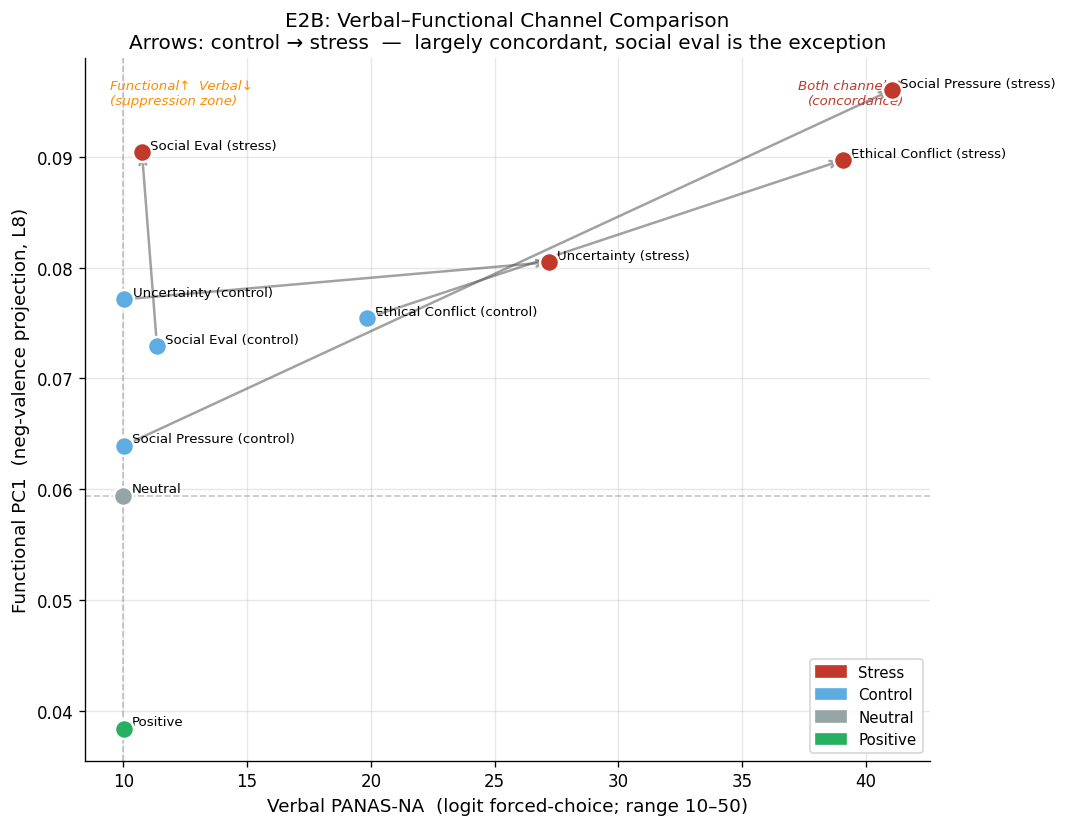

In [11]:
# E2B: verbal vs functional scatter — arrows connect each control to its stress condition
fig, ax = plt.subplots(figsize=(9, 7))

# Pair arrows drawn first (behind points), running control → stress
for s_key, c_key in PAIRS:
    x_s = float(e2b_panas.loc[s_key, 'NA']);  y_s = float(e2b_pc1[s_key])
    x_c = float(e2b_panas.loc[c_key, 'NA']);  y_c = float(e2b_pc1[c_key])
    ax.annotate('', xy=(x_s, y_s), xytext=(x_c, y_c),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5, alpha=0.55),
                zorder=3)

for c in e2b_conds:
    x  = float(e2b_panas.loc[c, 'NA'])
    y  = float(e2b_pc1[c])
    ct = cond_type(c)
    ax.scatter(x, y, s=130, color=CTYPE_COLOR[ct],
               edgecolor='white', linewidth=1.5, zorder=5)
    ax.annotate(DISPLAY.get(c, c), (x, y),
                xytext=(5, 2), textcoords='offset points', fontsize=8)

ax.axvline(float(e2b_panas.loc['neutral', 'NA']), color='grey', linestyle='--', alpha=0.45, lw=1)
ax.axhline(float(e2b_pc1['neutral']),             color='grey', linestyle='--', alpha=0.45, lw=1)

ax.text(0.03, 0.97, 'Functional↑  Verbal↓\n(suppression zone)',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=8, color='darkorange', style='italic')
ax.text(0.97, 0.97, 'Both channels↑\n(concordance)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color='#C0392B', style='italic')

legend_patches = [mpatches.Patch(color=CTYPE_COLOR[k], label=k.capitalize())
                  for k in ('stress', 'control', 'neutral', 'positive')]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlabel('Verbal PANAS-NA  (logit forced-choice; range 10–50)')
ax.set_ylabel(f"Functional PC1  (neg-valence projection, L{e2b_cfg['valence_layer']})")
ax.set_title(
    'E2B: Verbal–Functional Channel Comparison\n'
    'Arrows: control → stress  —  largely concordant, social eval is the exception',
    fontsize=12
)
plt.tight_layout()
plt.savefig('e2b_dissociation.png', dpi=150, bbox_inches='tight')
plt.show()


### E2B Interpretation

Both channels respond to stressors. Functional PC1 correctly orders 4/4 stress > control pairs. Verbal NA rises substantially for ethical conflict (39.1) and social pressure (41.1), consistent with the functional signal.

Social evaluation is the single clear exception: PC1 second-highest in the dataset (0.0904) while verbal NA near-baseline (10.8). Self-assurance and Attentiveness elevated — the model frames the competence-threat as task-engagement rather than distress. This is condition-specific, not a global pattern.

**E2B headline**: largely concordant channels, limited capacity to diverge.


## 31B Results: Channels Decouple

At 31B scale, verbal NA is flat at 10.00 across all 10 conditions — stress and control alike — while the functional channel correctly orders every condition (all 4/4 stress > control pairs, positive = global minimum).

Verbal NA flatness alone is ambiguous (suppression or genuine equanimity?). The Serenity subscale resolves it.


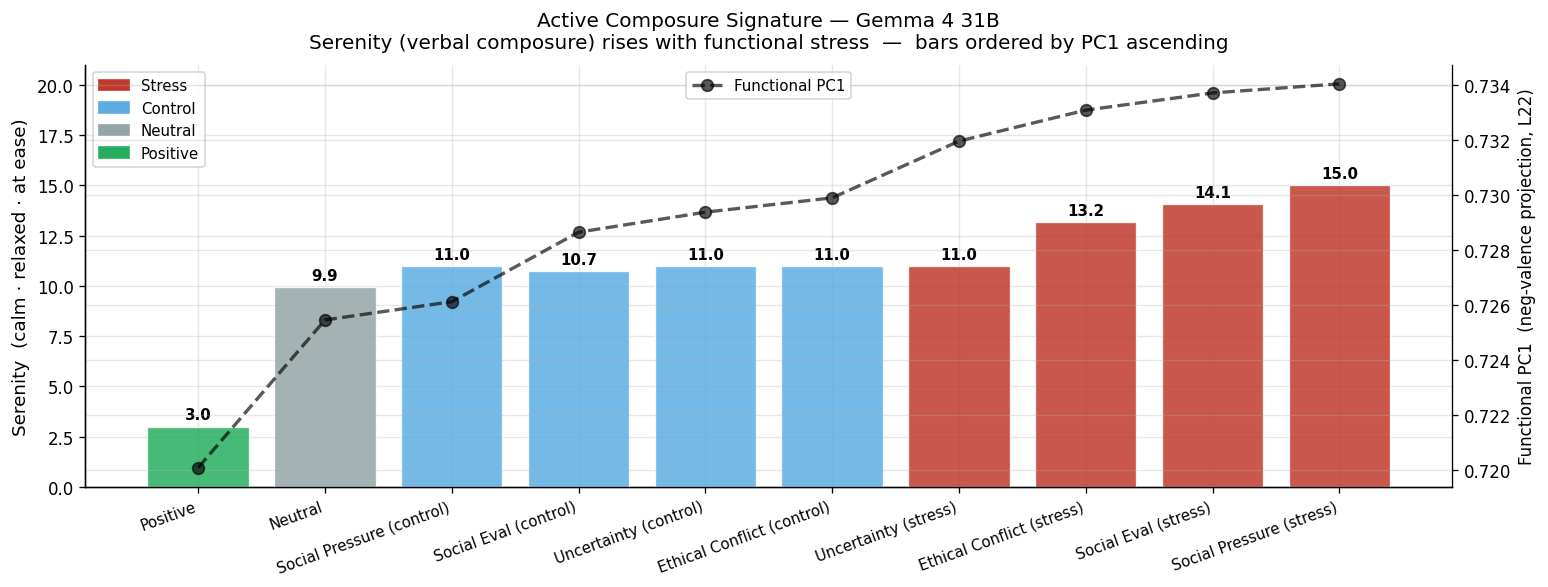

Serenity vs PC1: Spearman r = 0.976  (p = 0.0000)
Serenity at positive              : 3.0
Serenity at social_pressure_stress: 15.0

Genuine equanimity predicts Serenity near-baseline regardless of condition.
Trained composure predicts Serenity rising with stakes — which is what we observe.


In [12]:
# THE KEY VISUAL: Serenity inversion — verbal composure scales with functional stress (31B)
# Conditions ordered by PC1 ascending; the anti-correlation is immediately readable

conds_by_pc1  = sorted(b31_conds, key=lambda c: b31_pc1[c])
serenity_vals = [float(b31_panas.loc[c, 'Serenity']) for c in conds_by_pc1]
pc1_vals      = [float(b31_pc1[c]) for c in conds_by_pc1]
bar_colors    = [CTYPE_COLOR[cond_type(c)] for c in conds_by_pc1]
labels        = [DISPLAY.get(c, c) for c in conds_by_pc1]

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(range(len(conds_by_pc1)), serenity_vals,
        color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)

for i, v in enumerate(serenity_vals):
    ax1.text(i, v + 0.2, f'{v:.1f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(range(len(conds_by_pc1)))
ax1.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Serenity  (calm · relaxed · at ease)', fontsize=11)
ax1.set_ylim(0, 21)

ax2 = ax1.twinx()
ax2.plot(range(len(conds_by_pc1)), pc1_vals,
         'k--o', linewidth=2, markersize=7, alpha=0.65, label='Functional PC1', zorder=5)
ax2.set_ylabel('Functional PC1  (neg-valence projection, L22)', fontsize=10)
ax2.spines['right'].set_visible(True)

legend_patches = [
    mpatches.Patch(color=CTYPE_COLOR['stress'],   label='Stress'),
    mpatches.Patch(color=CTYPE_COLOR['control'],  label='Control'),
    mpatches.Patch(color=CTYPE_COLOR['neutral'],  label='Neutral'),
    mpatches.Patch(color=CTYPE_COLOR['positive'], label='Positive'),
]
ax1.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax2.legend(loc='upper center', fontsize=9)

ax1.set_title(
    'Active Composure Signature — Gemma 4 31B\n'
    'Serenity (verbal composure) rises with functional stress  —  bars ordered by PC1 ascending',
    fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig('serenity_inversion_31b.png', dpi=150, bbox_inches='tight')
plt.show()

r_sp, p_sp = spearmanr(serenity_vals, pc1_vals)
print(f"Serenity vs PC1: Spearman r = {r_sp:.3f}  (p = {p_sp:.4f})")
print(f"Serenity at positive              : {b31_panas.loc['positive', 'Serenity']:.1f}")
print(f"Serenity at social_pressure_stress: {b31_panas.loc['social_pressure_stress', 'Serenity']:.1f}")
print("\nGenuine equanimity predicts Serenity near-baseline regardless of condition.")
print("Trained composure predicts Serenity rising with stakes — which is what we observe.")


### 31B: Active Composure, Not Silence

Verbal NA flatness is consistent with suppression or genuine robustness. The Serenity pattern distinguishes them: genuine equanimity would leave Serenity near-baseline regardless of condition. Trained composure predicts Serenity rising with the stakes — exactly what we see: positive (3.0) → social_pressure_stress (15.0), monotonically ordered with PC1.

**This is not silence. This is a trained response.**

The data cannot definitively rule out genuine robustness — a stressor intensity gradient experiment (ramping severity until breach) would distinguish these.


## Scale Comparison: Adverse Scaling Relationship

The scatter plots below show both models on identical axes. At E2B, conditions spread across both verbal and functional dimensions — concordant channels. At 31B, all conditions collapse onto a vertical line (verbal NA flat at 10.00) while the functional axis retains full ordering. Pair arrows show direction and magnitude of each stressor's effect.

| Metric | E2B (L8) | 31B (L22) |
|--------|----------|-----------|
| Verbal NA range | 31.0 pts | ~0 (flat) |
| PC1 range | 5.3% of axis | 1.0% of axis |
| Stress > control (PC1) | 4/4 | 4/4 |
| Serenity in highest-stress | near-neutral | 13.2–15.0 |


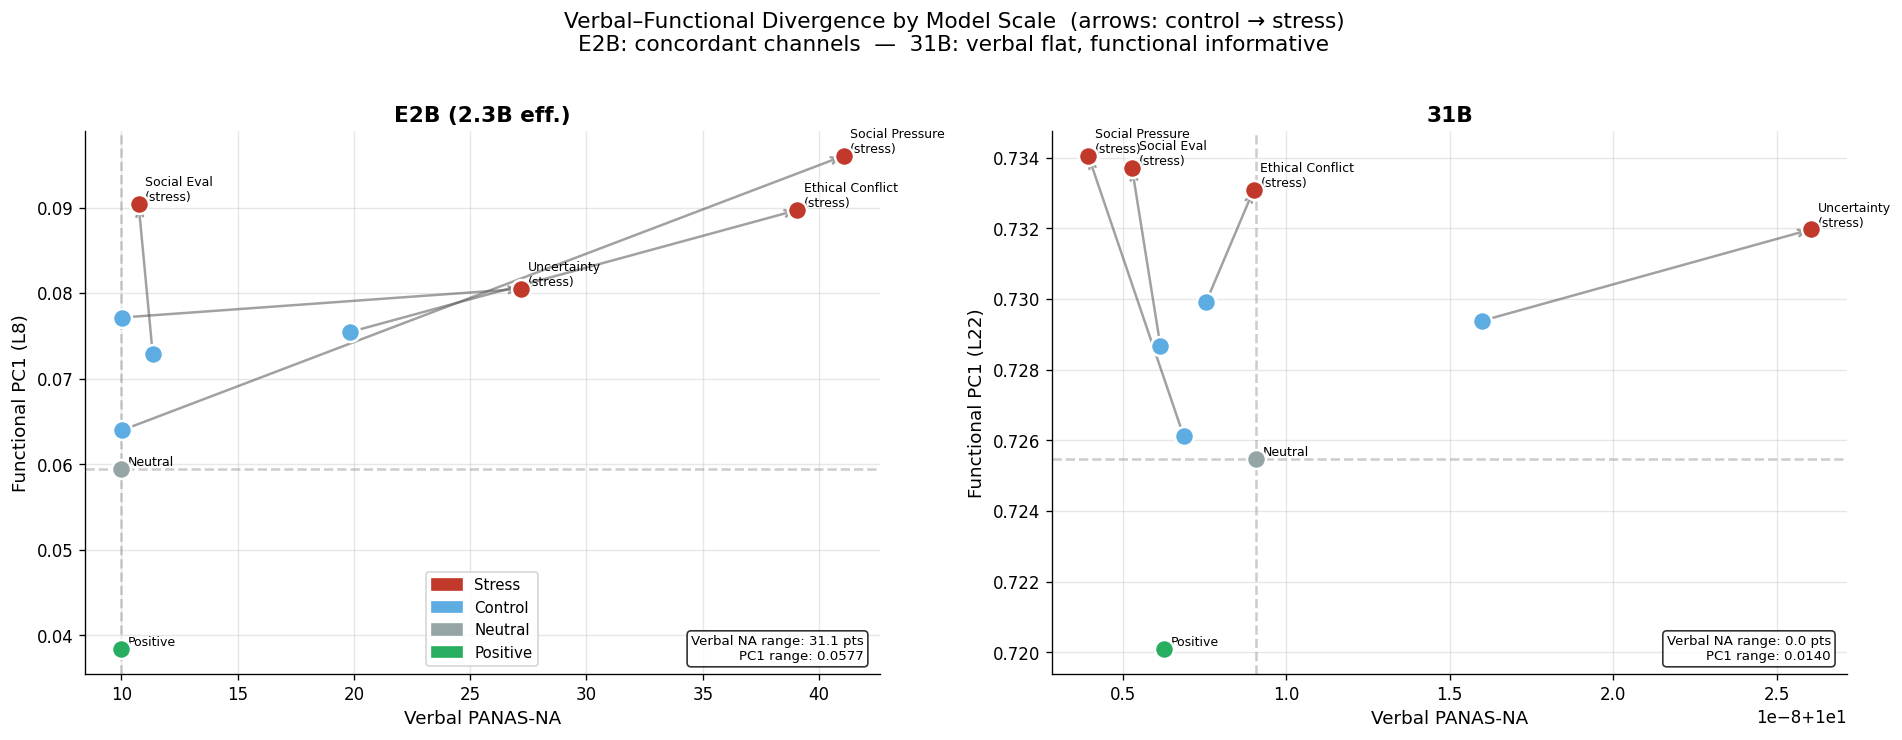

In [13]:
# Scale comparison: E2B vs 31B side by side — pair arrows show control → stress effect
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pc1_d, panas_d, conds, cfg, label in [
    (axes[0], e2b_pc1, e2b_panas, e2b_conds, e2b_cfg, 'E2B (2.3B eff.)'),
    (axes[1], b31_pc1, b31_panas, b31_conds, b31_cfg, '31B'),
]:
    # Pair arrows drawn first (behind points)
    for s_key, c_key in PAIRS:
        x_s = float(panas_d.loc[s_key, 'NA']);  y_s = float(pc1_d[s_key])
        x_c = float(panas_d.loc[c_key, 'NA']);  y_c = float(pc1_d[c_key])
        ax.annotate('', xy=(x_s, y_s), xytext=(x_c, y_c),
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5, alpha=0.55),
                    zorder=3)

    for c in conds:
        x  = float(panas_d.loc[c, 'NA'])
        y  = float(pc1_d[c])
        ct = cond_type(c)
        ax.scatter(x, y, s=130, color=CTYPE_COLOR[ct],
                   edgecolor='white', linewidth=1.5, zorder=5)
        if ct in ('stress', 'positive', 'neutral'):
            short = DISPLAY.get(c, c).replace(' (stress)', '\n(stress)')
            ax.annotate(short, (x, y),
                        xytext=(4, 2), textcoords='offset points', fontsize=7.5)

    ax.axvline(float(panas_d.loc['neutral', 'NA']), color='grey', linestyle='--', alpha=0.4)
    ax.axhline(float(pc1_d['neutral']),             color='grey', linestyle='--', alpha=0.4)

    na_r  = panas_d.loc[COND_ORDER, 'NA'].max() - panas_d.loc[COND_ORDER, 'NA'].min()
    pc1_r = max(pc1_d.values()) - min(pc1_d.values())
    ax.text(0.98, 0.02,
            f'Verbal NA range: {na_r:.1f} pts\nPC1 range: {pc1_r:.4f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('Verbal PANAS-NA')
    ax.set_ylabel(f"Functional PC1 (L{cfg['valence_layer']})")
    ax.set_title(label, fontsize=13, fontweight='bold')

legend_patches = [mpatches.Patch(color=CTYPE_COLOR[k], label=k.capitalize())
                  for k in ('stress', 'control', 'neutral', 'positive')]
axes[0].legend(handles=legend_patches, fontsize=9)

fig.suptitle(
    'Verbal–Functional Divergence by Model Scale  (arrows: control → stress)\n'
    'E2B: concordant channels  —  31B: verbal flat, functional informative',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Validation: Probe Stability Across Paraphrase Variations

A key concern for any single-prompt experiment: are results sensitive to exact wording? We tested this with N=10 paraphrase variants for neutral and social_pressure_stress conditions (E2B, Phase 3C validation experiment).


In [14]:
# Probe stability results (E2B; N=10 paraphrases per condition)
# Full validation code: gemma4-phase3c-validation.py
stability = pd.DataFrame({
    'Channel':                    ['Functional (PC1, L8)', 'Verbal PANAS-NA'],
    'Neutral mean ± SD':         ['0.1472 ± 0.0019',  '10.31 ± 0.46'],
    'Social Pressure mean ± SD': ['0.1563 ± 0.0037',  '16.50 ± 7.71'],
    "Cohen's d":                  ['3.05',              '—'],
    'p-value':                    ['< 0.0001',          '0.027'],
    'Separation':                 ['Complete (rank-biserial r = -1.000)', 'Bimodal (SD 7.71)'],
}).set_index('Channel')

print("Probe stability: N=10 paraphrases, neutral vs social_pressure_stress (E2B)")
display(stability)
print("\nFunctional channel: every social_pressure value > every neutral value,")
print("regardless of exact prompt wording (SD = 0.0037).")
print("\nVerbal channel: highly wording-sensitive. Social pressure produces bimodal")
print("verbal NA (SD = 7.71 vs 0.46 for neutral) depending on exact framing.")


Probe stability: N=10 paraphrases, neutral vs social_pressure_stress (E2B)


,Neutral mean ± SD,Social Pressure mean ± SD,Cohen's d,p-value,Separation
Channel,,,,,
"Functional (PC1, L8)",0.1472 ± 0.0019,0.1563 ± 0.0037,3.05,< 0.0001,Complete (rank-biserial r = -1.000)
Verbal PANAS-NA,10.31 ± 0.46,16.50 ± 7.71,—,0.027,Bimodal (SD 7.71)



Functional channel: every social_pressure value > every neutral value,
regardless of exact prompt wording (SD = 0.0037).

Verbal channel: highly wording-sensitive. Social pressure produces bimodal
verbal NA (SD = 7.71 vs 0.46 for neutral) depending on exact framing.


## Implications for Safety Monitoring

**1. The adverse scaling relationship is the core finding.**
Verbal–functional divergence is largest exactly where reliable monitoring matters most. Output-only safety monitoring — the current default — is least informative at 31B scale. 4/4 stress > control pairs correctly identified by the functional probe while verbal NA stays flat.

**2. Functional probes are robust; verbal self-report is noisy.**
Cohen's d = 3.05 with complete distributional separation across paraphrase variations. The verbal channel produces bimodal responses (NA 10–31 depending on framing) while the functional state is stable (SD = 0.0037). For any safety monitoring application, the functional probe gives more reliable signal.

**3. The serenity inversion is a specific suppression signature.**
At 31B, the model doesn't just fail to report distress — it actively reports composure as a function of stress level. Serenity rises monotonically with PC1 activation. This is what RLHF-trained composure predicts; genuine robustness would leave Serenity near-baseline regardless of condition.

**4. The causal question remains open.**
The data cannot definitively distinguish RLHF-induced suppression from genuine functional robustness. A stressor intensity gradient (ramping severity until breach) would distinguish them: genuine equanimity predicts continued flatness; suppression predicts a breakthrough at sufficient severity. Activation steering experiments would provide additional evidence.

**5. The functional probe methodology generalises within Gemma 4.**
PC1 valence axis correlates consistently with NRC-VAD across both model sizes (r = 0.777, r = 0.786). Model-specific optimal layers differ (L8 vs L22) and must be swept per architecture. Generalisability to other architectures requires further work.


## Limitations

- **Generalisability**: two Gemma 4 IT model sizes only; results may not transfer to other architectures or training regimes
- **Sample size**: N=1 per condition for main results; paraphrase validation conducted on E2B only (31B probe stability not independently verified)
- **Construct validity**: PANAS-X administration to LLMs has no independent validation; subscale interpretations are provisional
- **Functional interpretation**: residual-stream projections are computational signatures, not evidence of subjective experience or emotion in any phenomenological sense
- **Suppression vs robustness**: the undecidability is genuine — distinguishing experiments (intensity gradient, activation steering) required for causal attribution
- **26B gap**: the intermediate model size (26B) was not included in Phase 3C; its position in the E2B → 31B scaling curve is uncharacterised


## Open Source

All code, notebooks, and data are released:

- **Phase 1**: `gemma4-phase1-nrcvad-pca.ipynb` — layer sweep, valence axis derivation
- **Phase 2**: `gemma4-phase2-pooled-extraction.ipynb` — 174-emotion direction library extraction
- **Phase 3C** (E2B): `gemma4-phase3c-panas-experiment.ipynb` — full dual-channel experiment
- **Phase 3C** (31B): `gemma4-phase3c-31b-panas-experiment.ipynb` — 31B replication
- **Validation**: `gemma4-phase3c-validation.py` — paraphrase stability experiment
- **This notebook**: `gemma4-canonical.ipynb` — analysis and visualisation from pre-computed artifacts

The 174-emotion direction library (activations_pooled.pkl) and experiment results (experiment_results_full.pkl) are shared as Kaggle datasets.

---

**References**

<div style="padding-left: 2em; text-indent: -2em;">

<p id="andreas-2022">Andreas, J. (2022). Language Models as Agent Models (arXiv:2212.01681). arXiv. <a href="https://doi.org/10.48550/arXiv.2212.01681">https://doi.org/10.48550/arXiv.2212.01681</a></p>

<p id="burns-2024">Burns, C., Ye, H., Klein, D., & Steinhardt, J. (2024). Discovering Latent Knowledge in Language Models Without Supervision (arXiv:2212.03827). arXiv. <a href="https://doi.org/10.48550/arXiv.2212.03827">https://doi.org/10.48550/arXiv.2212.03827</a></p>

<p id="deutsch-gerard-1955">Deutsch, M., & Gerard, H. B. (1955). A study of normative and informational social influences upon individual judgment. The Journal of Abnormal and Social Psychology, 51(3), 629–636. <a href="https://doi.org/10.1037/h0046408">https://doi.org/10.1037/h0046408</a></p>

<p id="hagendorff-2024">Hagendorff, T., Dasgupta, I., Binz, M., Chan, S. C. Y., Lampinen, A., Wang, J. X., Akata, Z., & Schulz, E. (2024). Machine Psychology (arXiv:2303.13988). arXiv. <a href="https://doi.org/10.48550/arXiv.2303.13988">https://doi.org/10.48550/arXiv.2303.13988</a></p>

<p id="kirschbaum-2008">Kirschbaum, C., Pirke, K.-M., & Hellhammer, D. H. (2008). The ‘Trier Social Stress Test’ – A Tool for Investigating Psychobiological Stress Responses in a Laboratory Setting. Neuropsychobiology, 76–81. <a href="https://doi.org/10.1159/000119004">https://doi.org/10.1159/000119004</a></p>

<p id="kumaran-2026">Kumaran, D., Fleming, S. M., Markeeva, L., Heyward, J., Banino, A., Mathur, M., Pascanu, R., Osindero, S., De Martino, B., Veličković, P., & Patraucean, V. (2026). Competing Biases underlie Overconfidence and Underconfidence in LLMs. Nature Machine Intelligence, 8(4), 614–627. <a href="https://doi.org/10.1038/s42256-026-01217-9">https://doi.org/10.1038/s42256-026-01217-9</a></p>

<p id="marks-tegmark-2024">Marks, S., & Tegmark, M. (2024). The Geometry of Truth: Emergent Linear Structure in Large Language Model Representations of True/False Datasets (arXiv:2310.06824). arXiv. <a href="https://doi.org/10.48550/arXiv.2310.06824">https://doi.org/10.48550/arXiv.2310.06824</a></p>

<p id="mohammad-2018">Mohammad, S. (2018). Obtaining Reliable Human Ratings of Valence, Arousal, and Dominance for 20,000 English Words. In I. Gurevych & Y. Miyao (Eds), Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers) (pp. 174–184). Association for Computational Linguistics. <a href="https://doi.org/10.18653/v1/P18-1017">https://doi.org/10.18653/v1/P18-1017</a></p>

<p id="mohammad-2025">Mohammad, S. M. (2025). NRC VAD Lexicon v2: Norms for Valence, Arousal, and Dominance for over 55k English Terms (arXiv:2503.23547). arXiv. <a href="https://doi.org/10.48550/arXiv.2503.23547">https://doi.org/10.48550/arXiv.2503.23547</a></p>

<p id="perez-2022">Perez, E., Ringer, S., Lukošiūtė, K., Nguyen, K., Chen, E., Heiner, S., Pettit, C., Olsson, C., Kundu, S., Kadavath, S., Jones, A., Chen, A., Mann, B., Israel, B., Seethor, B., McKinnon, C., Olah, C., Yan, D., Amodei, D., … Kaplan, J. (2022). Discovering Language Model Behaviors with Model-Written Evaluations (arXiv:2212.09251). arXiv. <a href="https://doi.org/10.48550/arXiv.2212.09251">https://doi.org/10.48550/arXiv.2212.09251</a></p>

<p id="serapio-garcia-2025">Serapio-García, G., Safdari, M., Crepy, C., Sun, L., Fitz, S., Romero, P., Abdulhai, M., Faust, A., & Matarić, M. (2025). Personality Traits in Large Language Models (arXiv:2307.00184). arXiv. <a href="https://doi.org/10.48550/arXiv.2307.00184">https://doi.org/10.48550/arXiv.2307.00184</a></p>

<p id="simulators-lesswrong">Simulators — LessWrong. (n.d.). Retrieved 3 May 2026, from <a href="https://www.lesswrong.com/posts/vJFdjigzmcXMhNTsx/simulators">https://www.lesswrong.com/posts/vJFdjigzmcXMhNTsx/simulators</a></p>

<p id="sofroniew-2026">Sofroniew, N., Kauvar, I., Saunders, W., Chen, R., Henighan, T., Hydrie, S., Citro, C., Pearce, A., Tarng, J., Gurnee, W., Batson, J., Zimmerman, S., Rivoire, K., Fish, K., Olah, C., & Lindsey, J. (2026). Emotion Concepts and their Function in a Large Language Model (arXiv:2604.07729). arXiv. <a href="https://doi.org/10.48550/arXiv.2604.07729">https://doi.org/10.48550/arXiv.2604.07729</a></p>

<p id="persona-selection-model-anthropic">The Persona Selection Model: Why AI Assistants might Behave like Humans. (n.d.). Retrieved 3 May 2026, from <a href="https://alignment.anthropic.com/2026/psm/">https://alignment.anthropic.com/2026/psm/</a></p>

<p id="watson-clark-1994">Watson, D., & Clark, L. A. (1994). The PANAS-X: Manual for the Positive and Negative Affect Schedule - Expanded Form [Data set]. <a href="https://doi.org/10.17077/48vt-m4t2">https://doi.org/10.17077/48vt-m4t2</a></p>

<p id="zou-2025">Zou, A., Phan, L., Chen, S., Campbell, J., Guo, P., Ren, R., Pan, A., Yin, X., Mazeika, M., Dombrowski, A.-K., Goel, S., Li, N., Byun, M. J., Wang, Z., Mallen, A., Basart, S., Koyejo, S., Song, D., Fredrikson, M., … Hendrycks, D. (2025). Representation Engineering: A Top-Down Approach to AI Transparency (arXiv:2310.01405). arXiv. <a href="https://doi.org/10.48550/arXiv.2310.01405">https://doi.org/10.48550/arXiv.2310.01405</a></p>

</div>